# Rest & Recreation Custom Clothing Recommendation (Backup Notebook)

사용자 입력 이미지에 대해 자동으로 부위(상의/하의/원피스 등) 및 주요 색상을 탐지하고 추천 목록을 생성합니다.

In [1]:
import os, sys, colorsys
if sys.platform == 'win32':
    try: sys.stdout.reconfigure(encoding='utf-8')
    except: pass
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from scipy.sparse import hstack, csr_matrix
from recommender import ClothingRecommender, detect_color_label_from_image, extract_hsv_histogram
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)
print('Libraries loaded OK')

Libraries loaded OK


In [2]:
rec = ClothingRecommender('rest_recreation_600_labeled.csv', weight_mode='balanced')
print('Dataset loaded:', len(rec.df), 'items')

Dataset loaded: 760 items


## Custom Image Settings & Automatic Category / Color Detection

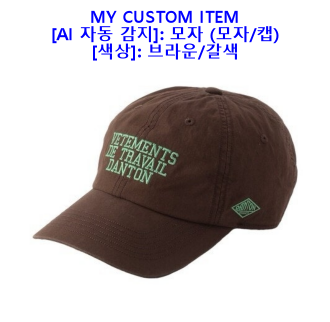

In [3]:
# ====== EDIT THESE VALUES ======
CUSTOM_IMAGE_PATH = r"c:\Users\Win11Pro\Desktop\rest\옷11.jpg"
CUSTOM_NAME       = 'MY CUSTOM ITEM'
CUSTOM_CATEGORY   = None                        # 대분류 자동 감지 (원피스, 상의, 하의 등)
CUSTOM_SUB_CAT    = None                        # 소분류 자동 감지
CUSTOM_FIT        = '오버핏'
# ================================

if os.path.exists(CUSTOM_IMAGE_PATH):
    detected_main_cat, detected_sub_cat, confidence = rec.predict_category_from_image(CUSTOM_IMAGE_PATH)
    detected_color = detect_color_label_from_image(CUSTOM_IMAGE_PATH)
    
    CUSTOM_CATEGORY = CUSTOM_CATEGORY or detected_main_cat
    CUSTOM_SUB_CAT = CUSTOM_SUB_CAT or detected_sub_cat
    
    plt.figure(figsize=(4, 4))
    plt.imshow(Image.open(CUSTOM_IMAGE_PATH))
    plt.title(f'{CUSTOM_NAME}\n[AI 자동 감지]: {CUSTOM_CATEGORY} ({CUSTOM_SUB_CAT})\n[색상]: {detected_color}', color='blue', fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.show()
else:
    print(f"❌ 이미지 파일을 찾을 수 없습니다: {CUSTOM_IMAGE_PATH}")

## Background Masking Visualizer

In [4]:
CROP_TOP    = 0.22
CROP_BOTTOM = 0.90
CROP_LEFT   = 0.18
CROP_RIGHT  = 0.78
print('Crop settings initialized')

Crop settings initialized


## AI Recommendation

In [5]:
def recommend_custom_item(img_path, name, main_cat, sub_cat, fit, top_n=5):
    """
    recommender.py의 최신 recommend_by_custom_image 엔진을 직접 호출합니다.
    감지/지정된 카테고리와 100% 일치하는 상품만 우선적으로 추천 목록에 반환합니다.
    """
    res = rec.recommend_by_custom_image(
        img_path=img_path,
        name=name,
        fit=fit,
        main_category=main_cat,
        sub_category=sub_cat,
        top_n=top_n
    )
    return res.get('recommendations', [])

print('Recommend function ready! (recommender.py 엔진 연동 완료)')

Recommend function ready! (recommender.py 엔진 연동 완료)


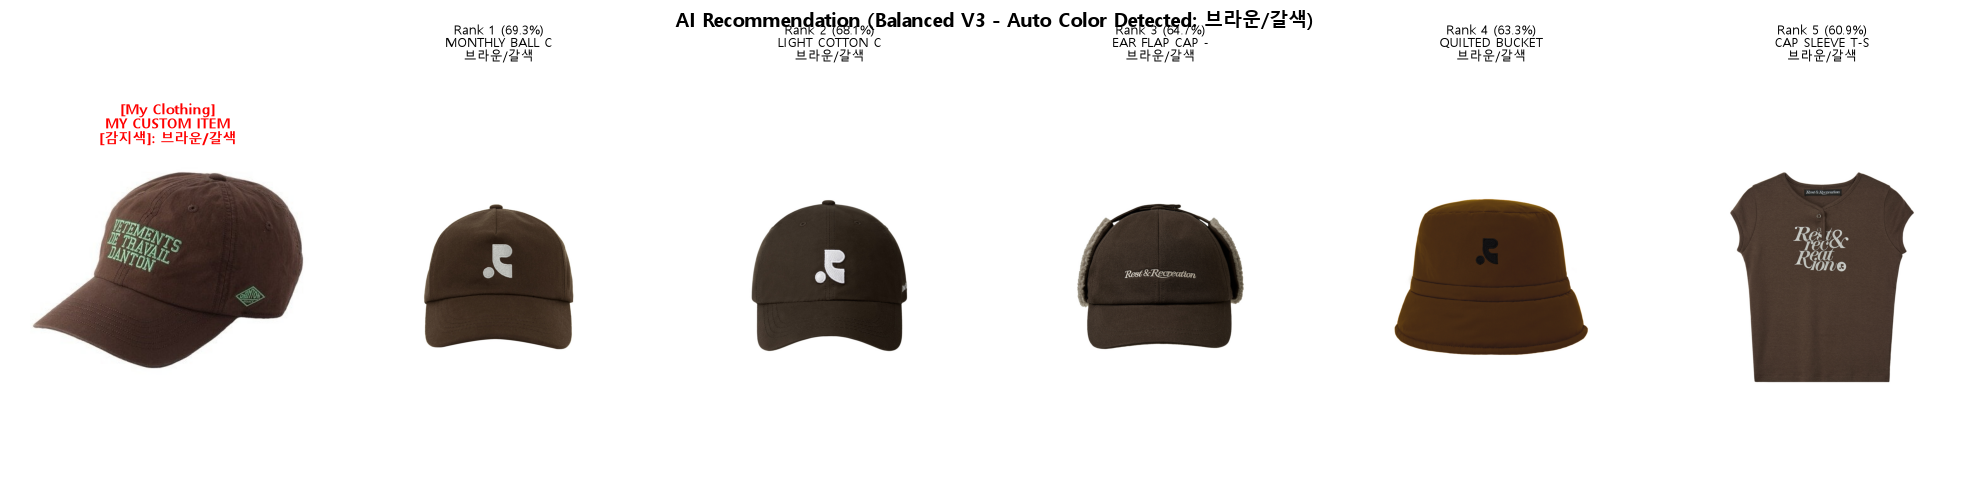

=== Results ===
1. MONTHLY BALL CAP SEPTEMBER - BROWN | 69.3% | 브라운/갈색
2. LIGHT COTTON CAP - BROWN | 68.1% | 브라운/갈색
3. EAR FLAP CAP - BROWN | 64.7% | 브라운/갈색
4. QUILTED BUCKET HAT - BROWN | 63.3% | 브라운/갈색
5. CAP SLEEVE T-SHIRT - BROWN | 60.9% | 브라운/갈색


In [6]:
real_color = detect_color_label_from_image(CUSTOM_IMAGE_PATH) if os.path.exists(CUSTOM_IMAGE_PATH) else '화이트'

recommendations = recommend_custom_item(
    img_path=CUSTOM_IMAGE_PATH, name=CUSTOM_NAME,
    main_cat=CUSTOM_CATEGORY, sub_cat=CUSTOM_SUB_CAT,
    fit=CUSTOM_FIT, top_n=5
)
if not recommendations:
    print('❌ 비교하고 싶으신 이미지 파일을 확인해주세요!')
else:
    fig, axes = plt.subplots(1, 6, figsize=(20, 5))
    axes[0].imshow(Image.open(CUSTOM_IMAGE_PATH))
    axes[0].set_title('[My Clothing]\n' + CUSTOM_NAME[:15] + '\n[감지색]: ' + real_color,
                      color='red', fontsize=10, fontweight='bold')
    axes[0].axis('off')
    for i, item in enumerate(recommendations, 1):
        rec_img_path = os.path.join('static/images', 'item_{}.jpg'.format(item['item_id']))
        if os.path.exists(rec_img_path):
            axes[i].imshow(Image.open(rec_img_path))
        score = item['similarity_score'] * 100
        title = 'Rank {} ({:.1f}%)\n{}\n{}'.format(
            i, score, str(item['product_name'])[:14], item['color_label'])
        axes[i].set_title(title, fontsize=9)
        axes[i].axis('off')
    plt.suptitle(f'AI Recommendation (Balanced V3 - Auto Color Detected: {real_color})', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()
    print('=== Results ===')
    for i, item in enumerate(recommendations, 1):
        print('{}. {} | {:.1f}% | {}'.format(i, item['product_name'], item['similarity_score']*100, item['color_label']))

In [7]:
# =================================================================
# 📊 색상 감지 정확도 평가 (Color Detection Accuracy Report)
# - CSV의 color_label  vs.  detect_color_label_from_image() 결과 비교
# - 카테고리별(원피스/상의/하의 등) 정확도 분석
# =================================================================
import os, pandas as pd

# ── 파라미터 조절 ────────────────────────────────────────────────
MAX_EVAL        = None    # 평가 이미지 수 (None = 전체 760개, 숫자가 클수록 오래 걸림)
CATEGORY_FILTER = None   # '원피스' / '상의' / '하의' / None(전체)
# ─────────────────────────────────────────────────────────────────

df_eval = rec.df.copy()

if CATEGORY_FILTER:
    df_eval = df_eval[df_eval['main_category'].str.contains(CATEGORY_FILTER, na=False)]
    print(f"카테고리 필터: '{CATEGORY_FILTER}' → {len(df_eval)}개")

if MAX_EVAL and len(df_eval) > MAX_EVAL:
    df_eval = df_eval.sample(MAX_EVAL, random_state=42)
    print(f"샘플링: {MAX_EVAL}개 무작위 선택")

img_dir = 'static/images'
print(f"\n▶ 평가 시작 (총 {len(df_eval)}개)...")

results = []
for idx, row in df_eval.iterrows():
    img_path = os.path.join(img_dir, f"item_{idx}.jpg")
    if not os.path.exists(img_path):
        continue
    csv_label  = str(row['color_label'])
    pred_label = detect_color_label_from_image(img_path)
    if pred_label is None:
        pred_label = '감지실패'
    match = (csv_label == pred_label)
    results.append({
        'idx':        idx,
        'category':   str(row.get('main_category', '?')),
        'csv_label':  csv_label,
        'pred_label': pred_label,
        'match':      match,
        'product':    str(row.get('product_name', ''))[:45],
    })

res_df = pd.DataFrame(results)
total   = len(res_df)
correct = int(res_df['match'].sum())
accuracy = correct / total * 100 if total > 0 else 0

print(f"\n{'='*55}")
print(f"  ✅ 전체 정확도:  {correct}/{total}  ({accuracy:.1f}%)")
print(f"{'='*55}")

# ── 색상별 정확도 바 차트 ─────────────────────────────────────────
print("\n📌 색상별 정확도:")
emoji_map = {
    '블랙':'⚫','화이트':'⚪','그레이':'🩶','베이지/아이보리':'🟡',
    '브라운/갈색':'🟫','블루':'🔵','네이비':'🌊','소라/스카이블루':'🩵',
    '핑크/레드':'🔴','그린':'🟢'
}
color_acc = (
    res_df.groupby('csv_label')['match']
    .agg(맞음='sum', 전체='count')
)
color_acc['정확도'] = (color_acc['맞음'] / color_acc['전체'] * 100).round(1)
color_acc = color_acc.sort_values('정확도', ascending=True)

for c_label, r in color_acc.iterrows():
    em  = emoji_map.get(c_label, '🎨')
    bar = '█' * int(r['정확도'] / 5) + '░' * (20 - int(r['정확도'] / 5))
    print(f"  {em} {c_label:12s} [{bar}] {r['정확도']:5.1f}%  ({int(r['맞음'])}/{int(r['전체'])})")

# ── 카테고리별 정확도 ─────────────────────────────────────────────
print("\n📂 카테고리별 정확도:")
cat_acc = (
    res_df.groupby('category')['match']
    .agg(맞음='sum', 전체='count')
)
cat_acc['정확도'] = (cat_acc['맞음'] / cat_acc['전체'] * 100).round(1)
cat_acc = cat_acc.sort_values('정확도', ascending=False)

for cat, r in cat_acc.iterrows():
    bar = '█' * int(r['정확도'] / 5) + '░' * (20 - int(r['정확도'] / 5))
    print(f"  📁 {str(cat)[:12]:12s} [{bar}] {r['정확도']:5.1f}%  ({int(r['맞음'])}/{int(r['전체'])})")

# ── 오감지 상위 15건 ─────────────────────────────────────────────
wrong = res_df[~res_df['match']].copy()
print(f"\n❌ 오감지 사례 (총 {len(wrong)}건, 상위 15개):")
print(f"  {'ID':>4}  {'CSV라벨':12}  {'감지결과':12}  {'카테고리':8}  상품명")
print(f"  {'-'*72}")
for _, r in wrong.head(15).iterrows():
    print(f"  {int(r['idx']):4d}  {r['csv_label']:12}  {r['pred_label']:12}  {r['category'][:8]:8}  {r['product']}")

# ── 혼동 패턴 요약 ────────────────────────────────────────────────
print(f"\n🔀 주요 혼동 패턴 (CSV라벨 → 감지결과):")
confusion = (
    wrong.groupby(['csv_label','pred_label'])
    .size()
    .reset_index(name='건수')
    .sort_values('건수', ascending=False)
    .head(10)
)
for _, r in confusion.iterrows():
    print(f"  {r['csv_label']:14s}  →  {r['pred_label']:14s}  ({int(r['건수'])}건)")


▶ 평가 시작 (총 760개)...

  ✅ 전체 정확도:  699/760  (92.0%)

📌 색상별 정확도:
  🟫 브라운/갈색       [██████████████░░░░░░]  71.4%  (30/42)
  🟡 베이지/아이보리     [█████████████████░░░]  85.4%  (82/96)
  🩵 소라/스카이블루     [█████████████████░░░]  88.9%  (48/54)
  🔵 블루           [██████████████████░░]  91.2%  (62/68)
  🩶 그레이          [██████████████████░░]  92.6%  (113/122)
  ⚪ 화이트          [██████████████████░░]  94.1%  (64/68)
  🟢 그린           [██████████████████░░]  94.9%  (37/39)
  🔴 핑크/레드        [███████████████████░]  95.4%  (62/65)
  🌊 네이비          [███████████████████░]  96.8%  (60/62)
  ⚫ 블랙           [███████████████████░]  97.9%  (141/144)

📂 카테고리별 정확도:
  📁 가방           [████████████████████] 100.0%  (39/39)
  📁 니트 (KNIT)    [████████████████████] 100.0%  (71/71)
  📁 악세서리         [████████████████████] 100.0%  (17/17)
  📁 액세서리         [████████████████████] 100.0%  (23/23)
  📁 상의 (TOP)     [███████████████████░]  99.0%  (202/204)
  📁 하의 (BOTTOM)  [███████████████████░]  99.0%  (98/99)
  📁 모자           [██